In [128]:
import importlib
import Utils
importlib.reload(Utils)





<module 'Utils' from '/Users/sam/github/leafmap-sam/Utils.py'>

dates =  ['2025-04-30', '2025-05-05', '2025-05-10', '2025-05-15', '2025-05-20', '2025-05-25', '2025-05-30', '2025-06-04', '2025-06-09', '2025-06-14', '2025-06-19', '2025-06-24', '2025-06-29', '2025-07-04', '2025-07-09', '2025-07-14', '2025-07-19', '2025-07-24', '2025-07-29']
processing date  2025-04-30
base_url =  https://roda.sentinel-hub.com/sentinel-s2-l1c/tiles/14/Q/NG/2025/4/30/0/B08.jp2
base_url =  https://roda.sentinel-hub.com/sentinel-s2-l1c/tiles/14/Q/NG/2025/4/30/0/B11.jp2
b08 =  3247.0
b11 =  3214.9375
processing date  2025-05-05
base_url =  https://roda.sentinel-hub.com/sentinel-s2-l1c/tiles/14/Q/NG/2025/5/5/0/B08.jp2
base_url =  https://roda.sentinel-hub.com/sentinel-s2-l1c/tiles/14/Q/NG/2025/5/5/0/B11.jp2
b08 =  3238.0
b11 =  3271.125
processing date  2025-05-10
base_url =  https://roda.sentinel-hub.com/sentinel-s2-l1c/tiles/14/Q/NG/2025/5/10/0/B08.jp2
base_url =  https://roda.sentinel-hub.com/sentinel-s2-l1c/tiles/14/Q/NG/2025/5/10/0/B11.jp2
b08 =  3017.0
b11 =  3206.062

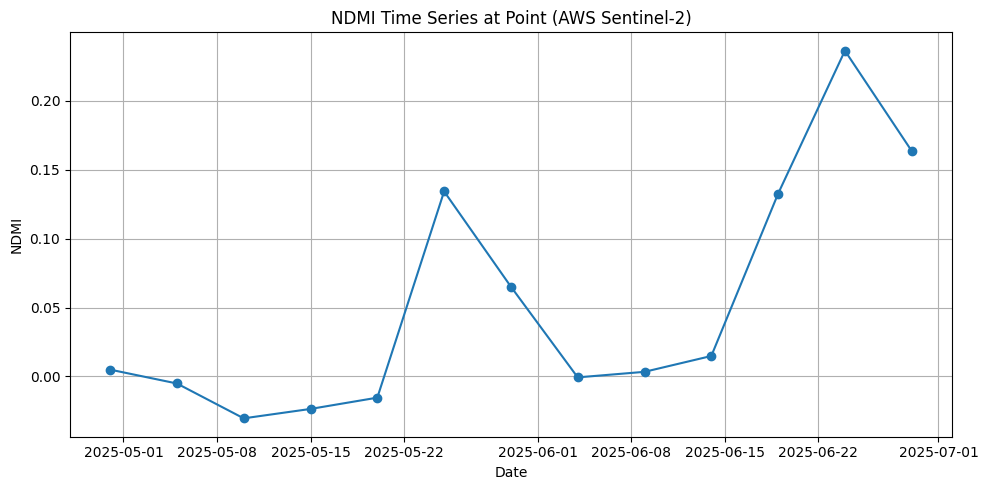

In [130]:
# Re-run the previous code after reset

dates = Utils.generate_date_range("2025-04-30", "2025-07-30",  "%Y-%m-%d", 5)
print("dates = ",dates)

# Output lists
ndmi_values = []
valid_dates = []

# Prepare folder
#os.makedirs("s2_point_series", exist_ok=True)

# Sample NDMI at the given point
for date in dates:
    print("processing date ",date)
    b08_path = Utils.download_band(date, "B08")
    b11_path = Utils.download_band(date, "B11")
    if not b08_path or not b11_path:
        continue

    try:
        with rasterio.open(b08_path) as src_b08, rasterio.open(b11_path) as src_b11:
            # Transform point to image coordinates
            #point_x, point_y = transform('EPSG:4326', src_b08.crs, [lon], [lat])
            #row, col = src_b08.index(point_x[0], point_y[0])
            #19.777411, -96.870102
            bounds = (-96.98, 19.53, -96.38, 20.03)
            shape = (10980, 10980)

            row,col = Utils.get_pixel_from_latlon(bounds, lat, lon, shape)

            b08 = src_b08.read(1)[row, col].astype(float)


            b11_data = src_b11.read(1)
            resampled_b11 = np.empty((10980, 10980), dtype="float32")
            reproject(
                source=b11_data,
                destination=resampled_b11,
                src_transform=src_b11.transform,
                src_crs=src_b11.crs,
                dst_transform=src_b08.transform,
                dst_crs=src_b08.crs,
                resampling=Resampling.bilinear
            )
            b11 = resampled_b11[row, col]

            
            
            print("b08 = ",b08)
            print("b11 = ",b11)

            if (b08 + b11) != 0:
                ndmi = (b08 - b11) / (b08 + b11)
                ndmi_values.append(ndmi)
                valid_dates.append(datetime.strptime(date, "%Y-%m-%d"))
    except Exception as e:
        print(f"Skipping {date} due to error: {e}")

# Plot NDMI vs Time
if valid_dates and ndmi_values:
    plt.figure(figsize=(10, 5))
    plt.plot(valid_dates, ndmi_values, marker='o', linestyle='-')
    plt.xlabel("Date")
    plt.ylabel("NDMI")
    plt.title("NDMI Time Series at Point (AWS Sentinel-2)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No NDMI values extracted. Try different dates or location.")

